In [19]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification

from SCIKIT.Lesson21GradientBoostingClassification import y_probability

X, y = make_classification(
    n_samples=3000,
    n_features=15,
    n_informative=9,
    n_redundant=3,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.15,
    flip_y=0.03,
    random_state=42
)

feature_names = [
    "income",
    "credit_score",
    "loan_amount",
    "employment_years",
    "debt_ratio",
    "savings",
    "age",
    "dependents",
    "assets",
    "financial_history",
    "risk_score",
    "payment_history",
    "loan_term",
    "account_age",
    "income_stability"
]

X = pd.DataFrame(
    X,
    columns=feature_names
)

y = pd.Series(
    y,
    name="loan_status"
)

print(X.shape)
print(y.value_counts())
X.head()


(3000, 15)
loan_status
0    1642
1    1358
Name: count, dtype: int64


,income,credit_score,loan_amount,employment_years,debt_ratio,savings,age,dependents,assets,financial_history,risk_score,payment_history,loan_term,account_age,income_stability
0,1.315783,0.490871,4.961069,-0.425435,-0.681551,-1.048155,-2.454936,-0.794336,2.468769,-2.889159,1.073149,0.770493,-1.545953,-3.358586,-0.565473
1,0.115173,-1.385931,1.297314,-0.175891,-0.909085,-3.742467,-1.650788,0.124237,2.826924,3.058178,-0.229392,-1.558186,-5.454871,-0.007427,2.623665
2,4.795473,1.656273,2.947193,-1.021040,-1.224108,-0.836297,1.851035,0.119154,1.210916,-0.242904,1.559833,-1.088340,-1.862305,2.358127,2.880938
3,5.754731,1.324854,4.266360,2.079007,1.230367,-0.081635,1.984795,0.781337,0.403325,-5.627951,2.030739,0.546287,3.102571,-0.100054,-0.816940
4,1.939590,1.627514,3.482338,-0.799083,-0.502034,-0.103466,1.688312,-0.835777,1.393657,-3.647154,-0.810485,1.938608,-0.382272,-1.021053,0.829353


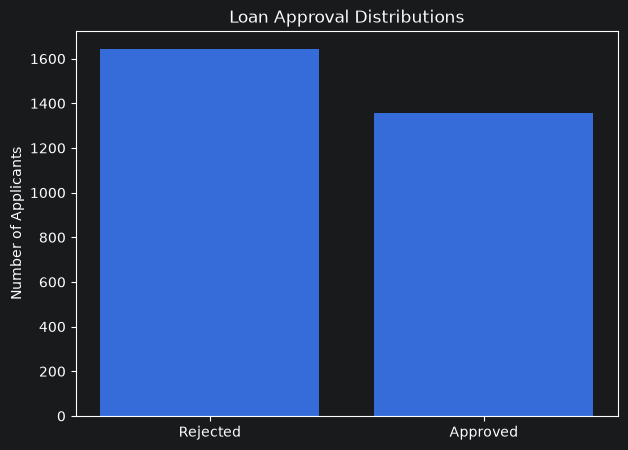

In [7]:
import matplotlib.pyplot as plt
counts=y.value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(["Rejected","Approved"],counts.values)
plt.ylabel("Number of Applicants")
plt.title("Loan Approval Distributions")
plt.show()


In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1536, 15)
Validation: (384, 15)
Test: (600, 15)


In [21]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=42
)

In [24]:
xgb_classifier.fit(
    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],

    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
print("Best iteration",
      xgb_classifier.best_iteration)
print("Best validation score",
      xgb_classifier.best_score)

Best iteration 375
Best validation score 0.21283450174041718


In [29]:
y_pred=xgb_classifier.predict(X_val)

y_pred

array([1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,

In [33]:
y_probability = xgb_classifier.predict_proba(
    X_test
)[:, 1]
y_probability

array([0.14322129, 0.06211488, 0.9887022 , 0.99901843, 0.96791327,
       0.5472427 , 0.03583239, 0.03255576, 0.26095316, 0.88081545,
       0.3773595 , 0.9827999 , 0.8439629 , 0.5441241 , 0.962869  ,
       0.01218651, 0.00301299, 0.25068688, 0.9416569 , 0.15863587,
       0.9845622 , 0.02143016, 0.12498108, 0.0033425 , 0.03706253,
       0.98511815, 0.07652317, 0.01982067, 0.99545693, 0.06168074,
       0.9961875 , 0.96851784, 0.9560517 , 0.8384755 , 0.99616987,
       0.01803862, 0.00814243, 0.02592774, 0.97555023, 0.7187129 ,
       0.80656976, 0.9931765 , 0.9974253 , 0.9970497 , 0.92222404,
       0.02385195, 0.01058603, 0.20305456, 0.05611108, 0.31893373,
       0.00260771, 0.01153522, 0.04208983, 0.98315305, 0.7377996 ,
       0.38835934, 0.01183451, 0.02947494, 0.02283197, 0.5289622 ,
       0.00447435, 0.03642657, 0.12193945, 0.0671781 , 0.0177515 ,
       0.11711667, 0.9929132 , 0.7690146 , 0.29175803, 0.03819655,
       0.00593349, 0.02936601, 0.25109202, 0.0086578 , 0.92253